In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 设置学术论文级别的图表样式
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")  # 使用和谐的色彩调色板

# 设置字体为学术期刊常用字体
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16

# 设置高分辨率和专业外观
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['lines.linewidth'] = 1.5

In [12]:
# Read Excel file
file_path = '../assets/papercompare.xlsx'
try:
    df = pd.read_excel(file_path)
    print("Data loaded successfully!")
    print(f"Data shape: {df.shape}")
    print("\nData preview:")
    display(df.head())
    print("\nColumn names:")
    print(df.columns.tolist())
except FileNotFoundError:
    print(f"File {file_path} not found, please check the file path")
except Exception as e:
    print(f"Error reading file: {e}")

Data loaded successfully!
Data shape: (23, 10)

Data preview:


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,GBLUP,LightGBM,SVR,DeepGS,DLGWAS,DNNGP,DNAWhisper Origin



Column names:
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']


In [13]:
# Data information and statistics
if 'df' in locals():
    print("Data information:")
    df.info()
    print("\nDescriptive statistics for numeric columns:")
    print(df.describe())

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  0 non-null      float64
 1   Unnamed: 1  5 non-null      object 
 2   Unnamed: 2  18 non-null     object 
 3   Unnamed: 3  19 non-null     object 
 4   Unnamed: 4  19 non-null     object 
 5   Unnamed: 5  19 non-null     object 
 6   Unnamed: 6  16 non-null     object 
 7   Unnamed: 7  19 non-null     object 
 8   Unnamed: 8  19 non-null     object 
 9   Unnamed: 9  19 non-null     object 
dtypes: float64(1), object(9)
memory usage: 1.9+ KB

Descriptive statistics for numeric columns:
       Unnamed: 0
count         0.0
mean          NaN
std           NaN
min           NaN
25%           NaN
50%           NaN
75%           NaN
max           NaN


In [14]:
# Create publication-quality bar chart (ignoring missing values)
if 'df' in locals() and not df.empty:
    # Remove rows with missing values
    df_clean = df.dropna()
    print(f"Original data rows: {len(df)}")
    print(f"Data rows after cleaning: {len(df_clean)}")
    print(f"Rows with missing values ignored: {len(df) - len(df_clean)}")
    
    if df_clean.empty:
        print("No data available after removing missing values")
    else:
        # Get column information
        numeric_columns = df_clean.select_dtypes(include=[np.number]).columns
        categorical_columns = df_clean.select_dtypes(include=['object']).columns
        
        print(f"Numeric columns: {list(numeric_columns)}")
        print(f"Categorical columns: {list(categorical_columns)}")
        
        # Define academic color palette
        colors = ['#2E86C1', '#28B463', '#F39C12', '#E74C3C', '#8E44AD', '#17A2B8']
        
        # Create main comparison chart
        fig, ax = plt.subplots(figsize=(10, 6))
        
        if len(categorical_columns) > 0 and len(numeric_columns) > 0:
            x_col = categorical_columns[0]
            
            if len(numeric_columns) == 1:
                # Single numeric column bar chart
                y_col = numeric_columns[0]
                bars = ax.bar(df_clean[x_col], df_clean[y_col], 
                             color=colors[0], alpha=0.8, edgecolor='black', linewidth=0.8)
                ax.set_xlabel(x_col.replace('_', ' ').title())
                ax.set_ylabel(y_col.replace('_', ' ').title())
                ax.set_title(f'Comparison of {y_col.replace("_", " ").title()} by {x_col.replace("_", " ").title()}')
                
                # Add value labels on bars
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                           f'{height:.2f}', ha='center', va='bottom', fontsize=9)
                
            else:
                # Multiple numeric columns grouped bar chart
                x = np.arange(len(df_clean))
                width = 0.8 / len(numeric_columns)
                
                for i, col in enumerate(numeric_columns):
                    bars = ax.bar(x + i * width, df_clean[col], width, 
                                 label=col.replace('_', ' ').title(),
                                 color=colors[i % len(colors)], alpha=0.8,
                                 edgecolor='black', linewidth=0.6)
                
                ax.set_xlabel(x_col.replace('_', ' ').title())
                ax.set_ylabel('Value')
                ax.set_title('Multi-metric Comparison')
                ax.set_xticks(x + width * (len(numeric_columns) - 1) / 2)
                ax.set_xticklabels(df_clean[x_col], rotation=45, ha='right')
                ax.legend(frameon=True, fancybox=True, shadow=True)
                
        elif len(numeric_columns) > 0:
            # Only numeric columns
            if len(numeric_columns) == 1:
                col = numeric_columns[0]
                bars = ax.bar(range(len(df_clean)), df_clean[col], 
                             color=colors[0], alpha=0.8, edgecolor='black', linewidth=0.8)
                ax.set_xlabel('Sample Index')
                ax.set_ylabel(col.replace('_', ' ').title())
                ax.set_title(f'Distribution of {col.replace("_", " ").title()}')
                
                # Add value labels
                for i, bar in enumerate(bars):
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                           f'{height:.2f}', ha='center', va='bottom', fontsize=8)
            else:
                # Multiple columns side by side
                x = np.arange(len(df_clean))
                width = 0.8 / len(numeric_columns)
                
                for i, col in enumerate(numeric_columns):
                    ax.bar(x + i * width, df_clean[col], width, 
                          label=col.replace('_', ' ').title(),
                          color=colors[i % len(colors)], alpha=0.8,
                          edgecolor='black', linewidth=0.6)
                
                ax.set_xlabel('Sample Index')
                ax.set_ylabel('Value')
                ax.set_title('Data Comparison')
                ax.set_xticks(x + width * (len(numeric_columns) - 1) / 2)
                ax.set_xticklabels(range(len(df_clean)))
                ax.legend(frameon=True, fancybox=True, shadow=True)
        
        # Improve chart appearance
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)
        
        plt.tight_layout()
        plt.show()
        
        # Save as high-quality image for publication
        fig.savefig('../assets/comparison_chart.png', dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        fig.savefig('../assets/comparison_chart.pdf', dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        print("High-quality charts saved as PNG and PDF formats")

Original data rows: 23
Data rows after cleaning: 0
Rows with missing values ignored: 23
No data available after removing missing values


NameError: name 'colors' is not defined

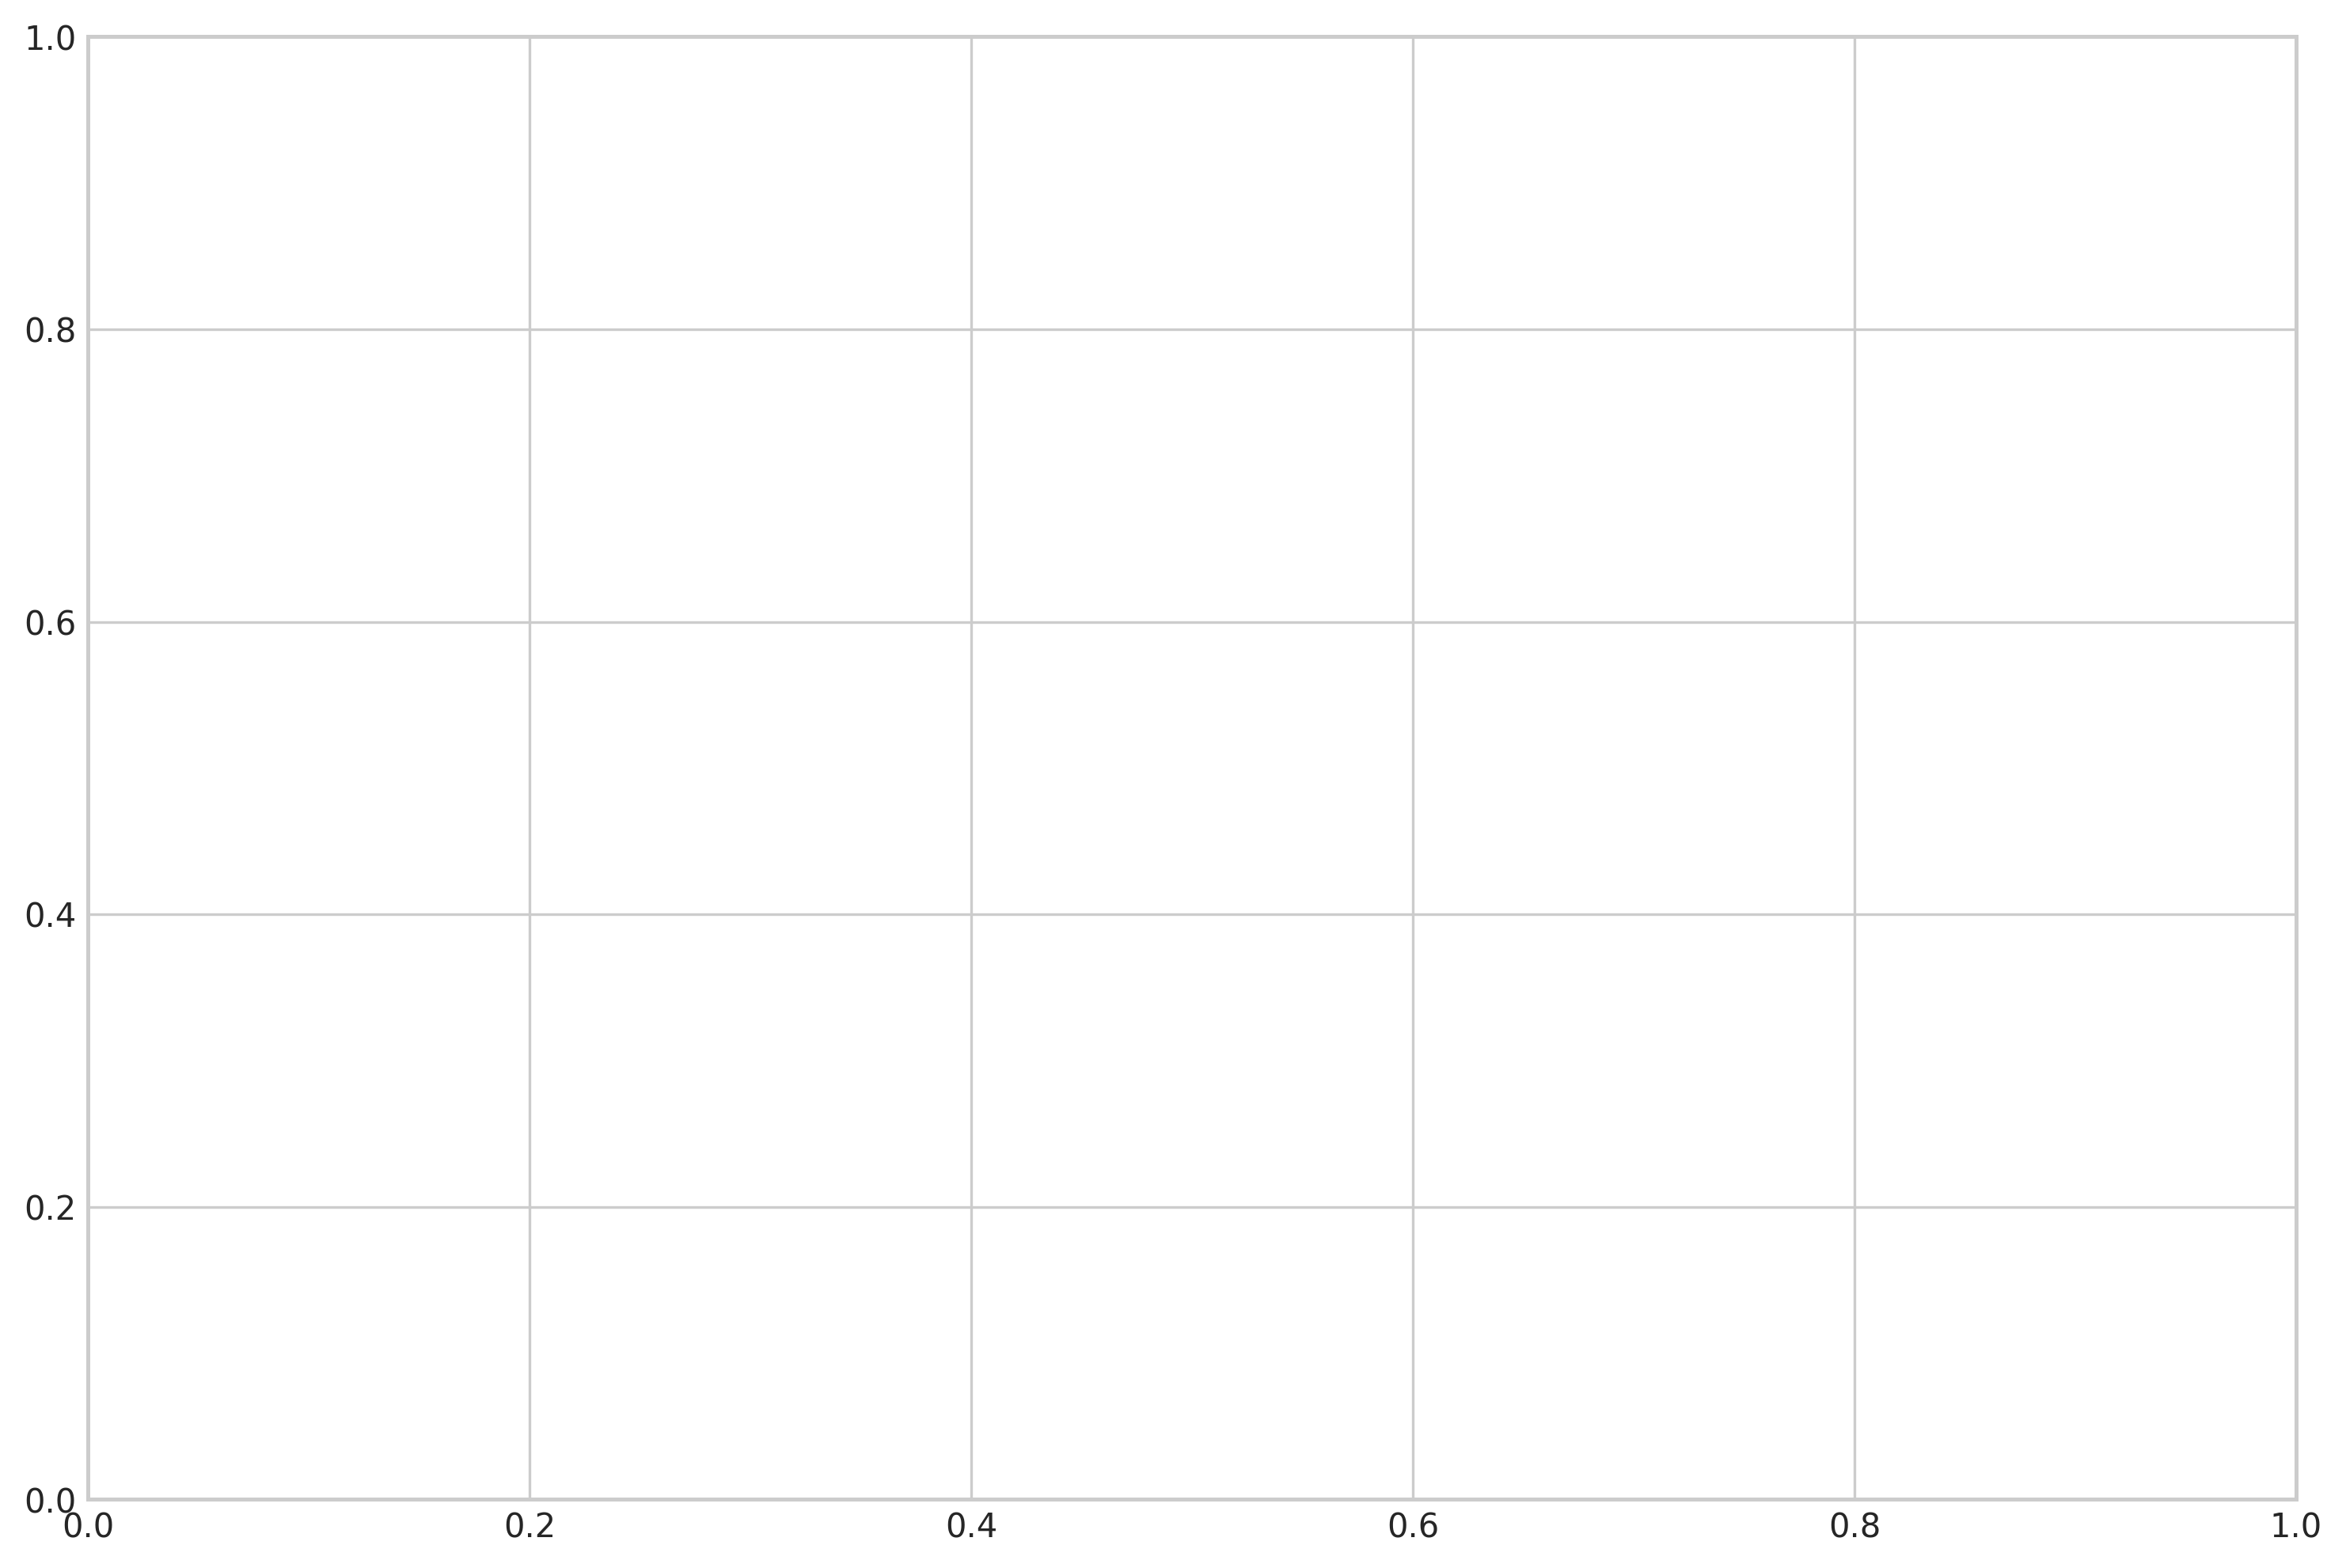

In [15]:
# Create comprehensive analysis panel for publication
if 'df' in locals() and not df.empty and 'df_clean' in locals():
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) > 0:
        # Create a professional multi-panel figure
        fig = plt.figure(figsize=(12, 8))
        
        if len(numeric_cols) >= 2:
            # Two-panel layout for comparison
            gs = fig.add_gridspec(1, 2, hspace=0.3, wspace=0.3)
            
            # Panel A: First metric
            ax1 = fig.add_subplot(gs[0, 0])
            bars1 = ax1.bar(range(len(df_clean)), df_clean[numeric_cols[0]], 
                           color=colors[0], alpha=0.8, edgecolor='black', linewidth=0.8)
            ax1.set_xlabel('Sample Index')
            ax1.set_ylabel(numeric_cols[0].replace('_', ' ').title())
            ax1.set_title('Panel A: ' + numeric_cols[0].replace('_', ' ').title())
            ax1.grid(True, alpha=0.3)
            
            # Panel B: Second metric
            ax2 = fig.add_subplot(gs[0, 1])
            bars2 = ax2.bar(range(len(df_clean)), df_clean[numeric_cols[1]], 
                           color=colors[1], alpha=0.8, edgecolor='black', linewidth=0.8)
            ax2.set_xlabel('Sample Index')
            ax2.set_ylabel(numeric_cols[1].replace('_', ' ').title())
            ax2.set_title('Panel B: ' + numeric_cols[1].replace('_', ' ').title())
            ax2.grid(True, alpha=0.3)
            
        else:
            # Single panel with detailed analysis
            ax = fig.add_subplot(111)
            bars = ax.bar(range(len(df_clean)), df_clean[numeric_cols[0]], 
                         color=colors[0], alpha=0.8, edgecolor='black', linewidth=0.8)
            ax.set_xlabel('Sample Index')
            ax.set_ylabel(numeric_cols[0].replace('_', ' ').title())
            ax.set_title('Data Analysis: ' + numeric_cols[0].replace('_', ' ').title())
            ax.grid(True, alpha=0.3)
            
            # Add statistical information
            mean_val = df_clean[numeric_cols[0]].mean()
            std_val = df_clean[numeric_cols[0]].std()
            ax.axhline(y=mean_val, color='red', linestyle='--', alpha=0.7, 
                      label=f'Mean = {mean_val:.2f}')
            ax.fill_between(range(len(df_clean)), mean_val - std_val, mean_val + std_val, 
                           alpha=0.2, color='red', label=f'±1 SD = {std_val:.2f}')
            ax.legend()
        
        # Apply consistent styling
        for ax in fig.get_axes():
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(1.2)
            ax.spines['bottom'].set_linewidth(1.2)
        
        plt.tight_layout()
        plt.show()
        
        # Save publication-ready figures
        fig.savefig('../assets/analysis_panel.png', dpi=300, bbox_inches='tight')
        fig.savefig('../assets/analysis_panel.pdf', dpi=300, bbox_inches='tight')
        print("Analysis panel saved in publication-ready formats")
        
        # Print summary statistics
        print("\nSummary Statistics:")
        print("="*50)
        for col in numeric_cols:
            print(f"{col.replace('_', ' ').title()}:")
            print(f"  Mean: {df_clean[col].mean():.3f}")
            print(f"  Std:  {df_clean[col].std():.3f}")
            print(f"  Min:  {df_clean[col].min():.3f}")
            print(f"  Max:  {df_clean[col].max():.3f}")
            print()